# Emotion Detection in Text Messages

This project is about building a machine learning model that can detect emotions in text. The model will analyze messages and classify them into emotions such as joy, sadness, anger, fear, love, and surprise.

![Project Image](img.jpg)

In [30]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

## --- Data Design ---

### Load Dataset

In [ ]:
df = pd.read_csv("combined_emotion.csv")

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_sentence"] = df["sentence"].apply(clean_text)

df.head()

,sentence,emotion
0,i just feel really helpless and heavy hearted,fear
1,ive enjoyed being able to slouch about relax a...,sad
2,i gave up my internship with the dmrg and am f...,fear
3,i dont know i feel so lost,sad
4,i am a kindergarten teacher and i am thoroughl...,fear


### Dataset Overview

The dataset contains over 422,000 text samples labeled with emotions.

There are no missing values, and the dataset consists of two columns:
- sentence: the input text
- emotion: the label

The dataset is imbalanced. Some emotions like joy and sadness are represented much more often than others like surprise. This may affect model performance.

In [32]:
df.info()
df["emotion"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 422746 entries, 0 to 422745
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   sentence  422746 non-null  str  
 1   emotion   422746 non-null  str  
dtypes: str(2)
memory usage: 6.5 MB


emotion
joy        143067
sad        121187
anger       59317
fear        49649
love        34554
suprise     14972
Name: count, dtype: int64

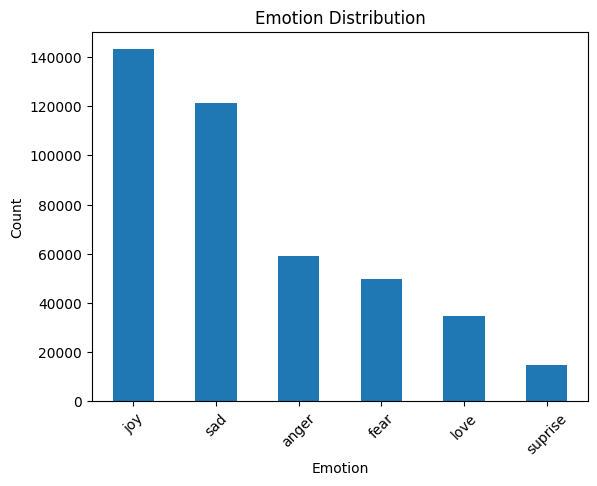

In [33]:
import matplotlib.pyplot as plt

df["emotion"].value_counts().plot(kind="bar")
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt

cv = CountVectorizer(stop_words="english", max_features=15)
word_counts = cv.fit_transform(df["clean_sentence"].fillna(""))
word_sums = word_counts.sum(axis=0).A1

words_df = pd.DataFrame({
    "word": cv.get_feature_names_out(),
    "count": word_sums
}).sort_values("count", ascending=False)

plt.bar(words_df["word"], words_df["count"])
plt.title("Most Common Words")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

KeyError: 'clean_sentence'

### Data Cleaning

In [ ]:
# Preview original vs cleaned text.
df[["sentence", "clean_sentence"]].head()

,sentence,emotion,clean_sentence
0,i just feel really helpless and heavy hearted,fear,i just feel really helpless and heavy hearted
1,ive enjoyed being able to slouch about relax a...,sad,ive enjoyed being able to slouch about relax a...
2,i gave up my internship with the dmrg and am f...,fear,i gave up my internship with the dmrg and am f...
3,i dont know i feel so lost,sad,i dont know i feel so lost
4,i am a kindergarten teacher and i am thoroughl...,fear,i am a kindergarten teacher and i am thoroughl...


### Train, Validation, and Test Split
The dataset is split into training, validation, and test sets.

The training set is used to train the model.  
The validation set is used to evaluate and improve the model during development.  
The test set is used for final evaluation.

Stratified splitting is used to maintain the same distribution of emotion labels across all sets.

In [ ]:
X = df["clean_sentence"]
y = df["emotion"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.50, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.40, random_state=42, stratify=y_temp
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 211373
Validation samples: 126823
Test samples: 84550


### Feature Extraction (TF-IDF)

In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

print("TF-IDF shape:", X_train_vec.shape)

TF-IDF shape: (211373, 5000)


## --- Modelling & Evaluation ---

### Training The Model

Class imbalance is handled using class weights in the model. 

This ensures that less frequent emotions are given more importance during training, which helps improve performance on minority classes.

In [ ]:
model = LogisticRegression(max_iter=200, class_weight="balanced")

model.fit(X_train_vec, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

### Validation Evaluation

The model achieves an accuracy of around 90%, which shows decent overall performance.

Performance is higher for more commonly seen emotions such as joy and sadness, while lower for less frequent emotions like surprise.

This shows that class imbalance still affects the model, even though class weights were used.

In [ ]:
from sklearn.metrics import classification_report

y_val_pred = model.predict(X_val_vec)

print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

       anger       0.88      0.93      0.90     17795
        fear       0.85      0.86      0.86     14895
         joy       0.97      0.88      0.92     42920
        love       0.72      0.95      0.82     10366
         sad       0.97      0.91      0.94     36355
     suprise       0.65      0.93      0.77      4492

    accuracy                           0.90    126823
   macro avg       0.84      0.91      0.87    126823
weighted avg       0.91      0.90      0.90    126823



### Test Evaluation


In [ ]:
y_test_pred = model.predict(X_test_vec)

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

       anger       0.88      0.93      0.91     11863
        fear       0.86      0.86      0.86      9930
         joy       0.97      0.88      0.92     28614
        love       0.71      0.96      0.82      6911
         sad       0.97      0.91      0.94     24238
     suprise       0.65      0.92      0.76      2994

    accuracy                           0.90     84550
   macro avg       0.84      0.91      0.87     84550
weighted avg       0.91      0.90      0.90     84550



### Confusion Matrix

The confusion matrix shows how the model predictions compare to the actual labels.
It helps identify which emotions are often confused with each other.

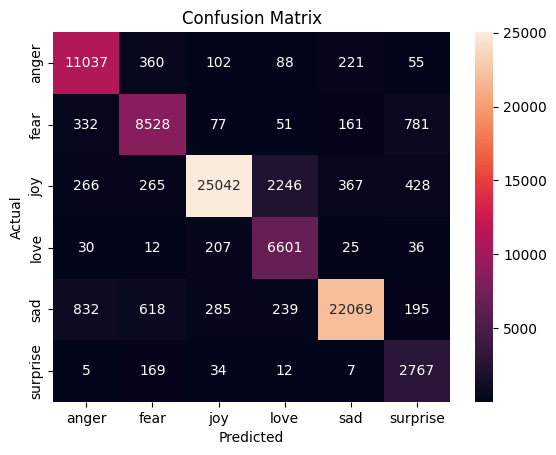

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = ["anger", "fear", "joy", "love", "sad", "surprise"]

cm = confusion_matrix(y_test, y_test_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

The confusion matrix shows that the model performs very well on more common emotions such as joy and sadness, with a high number of correct predictions.

Some confusion happens between similar emotions. For example, fear is sometimes predicted as surprise, and joy is sometimes confused with love.

The model also tends to over-predict the "surprise" class, which explains its lower precision.

### Model Performance per Emotion

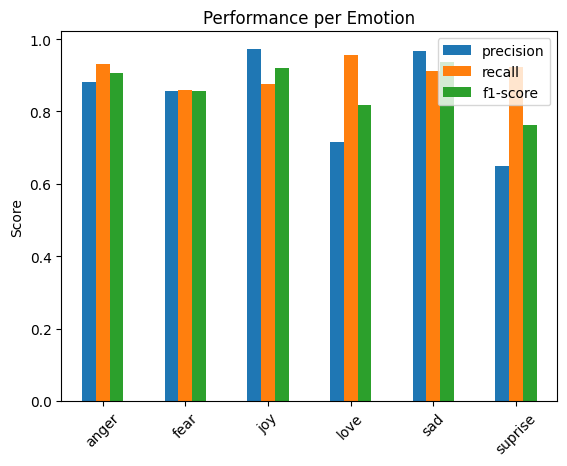

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

report = classification_report(y_test, y_test_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

report_df.iloc[:-3][["precision", "recall", "f1-score"]].plot(kind="bar")

plt.title("Performance per Emotion")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

This section is used to test the trained model on a custom string.

In [ ]:
custom_text = "have a nice day"

cleaned = clean_text(custom_text)
text_vec = vectorizer.transform([cleaned])

prediction = model.predict(text_vec)[0]

print("Text:", custom_text)
print("Predicted emotion:", prediction)